Please upload your dataset file


Saving train.csv to train.csv
✅ Loaded! Shape: (9800, 18)
   Row ID        Order ID Order Date Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156   08-11-17  11-11-17    Second Class    CG-12520   
1       2  CA-2017-152156   08-11-17  11-11-17    Second Class    CG-12520   
2       3  CA-2017-138688   12-06-17  16-06-17    Second Class    DV-13045   
3       4  US-2016-108966   11-10-16  18-10-16  Standard Class    SO-20335   
4       5  US-2016-108966   11-10-16  18-10-16  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal 

/tmp/ipykernel_9487/1362242272.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/tmp/ipykernel_9487/1362242272.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


✅ Data cleaned and features created!
KEY BUSINESS METRICS
Total Sales:     $2,261,536.78
Total Orders:    4,922
Avg Order Value: $230.77

SALES BY CATEGORY:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


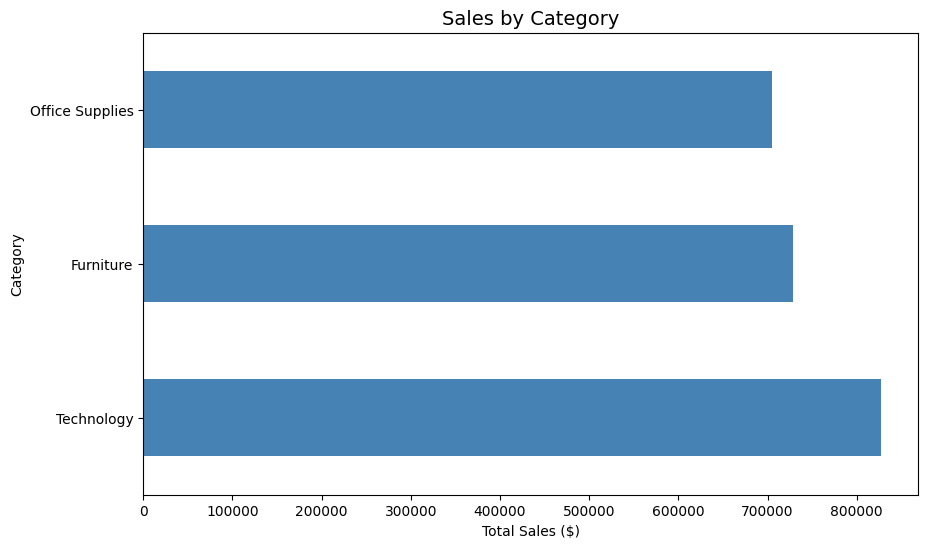

✅ All done!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Cleaned data downloaded to your computer!


In [1]:
# ============================================
# PROJECT 1: RETAIL SALES ANALYTICS
# COMPLETE WORKING CODE FOR GOOGLE COLAB
# ============================================

# Step 1: Upload your file
from google.colab import files
print("Please upload your dataset file")
uploaded = files.upload()

# Step 2: Load the file
import pandas as pd
import io

# Get the filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"✅ Loaded! Shape: {df.shape}")
print(df.head())

# Step 3: Clean data
df = df.drop_duplicates()
df['Postal Code'] = df['Postal Code'].fillna(0)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Step 4: Create new features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.strftime('%B')
df['Quarter'] = df['Order Date'].dt.quarter
df['Day_of_Week'] = df['Order Date'].dt.day_name()
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("✅ Data cleaned and features created!")

# Step 5: Key metrics
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
avg_order = df['Sales'].mean()

print("="*50)
print("KEY BUSINESS METRICS")
print("="*50)
print(f"Total Sales:     ${total_sales:,.2f}")
print(f"Total Orders:    {total_orders:,}")
print(f"Avg Order Value: ${avg_order:.2f}")

# Step 6: Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nSALES BY CATEGORY:")
print(category_sales)

# Step 7: Create chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
category_sales.plot(kind='barh', color='steelblue')
plt.title('Sales by Category', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.show()

print("✅ All done!")

# Step 8: Download cleaned data
df.to_csv('cleaned_retail_data.csv', index=False)
files.download('cleaned_retail_data.csv')
print("✅ Cleaned data downloaded to your computer!")